# Optical Flow
## Sparse Optical Flow

As always start by importing the relevant packages.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

Load the images `OF1.jpg` and `OF2.jpg` and change them to grayscale.

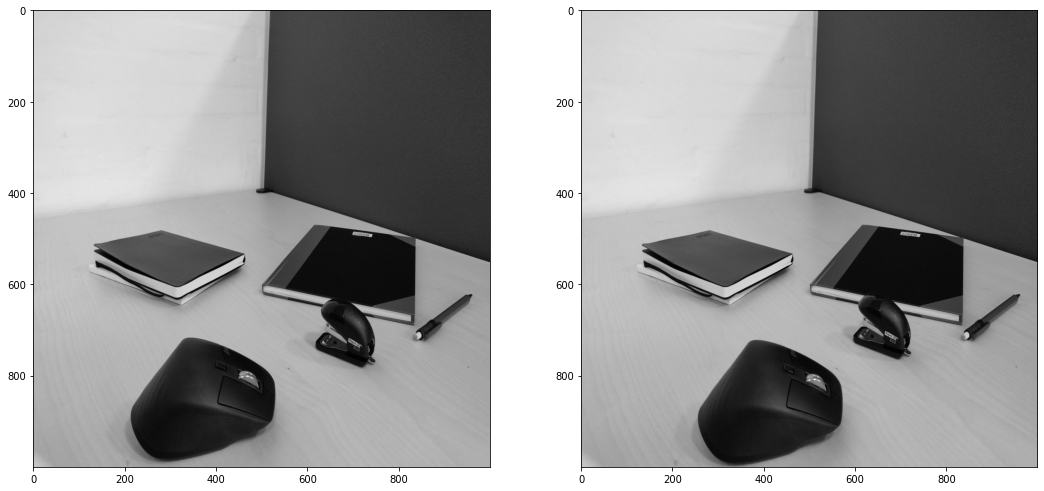

In [9]:
path = "C:/Users/peisz/OneDrive/Documents/Egyetem/DTU/3rd semester/PAS/Week 2/"

img1 = cv2.imread(path + 'OF1.jpg')
img2 = cv2.imread(path + 'OF2.jpg')

b,g,r = cv2.split(img1) # Changing the order from bgr to rgb so that matplotlib can show it
img1 = cv2.merge([r,g,b])
b,g,r = cv2.split(img2) # Changing the order from bgr to rgb so that matplotlib can show it
img2 = cv2.merge([r,g,b])

gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

plt.figure(figsize = (18,18))
plt.subplot(1,2,1)
plt.imshow(gray1, cmap = 'gray')
plt.subplot(1,2,2)
plt.imshow(gray2, cmap = 'gray')

They look pretty much the same. We can now use optical flow to find out how the objects in the picutures have moved. We do this by first using [`cv2.goodFeaturesToTrack`](https://docs.opencv.org/4.7.0/dd/d1a/group__imgproc__feature.html#ga1d6bb77486c8f92d79c8793ad995d541) to find features in the first image. You can play around with the parameters to see the difference.

In [10]:
# Find features to track using the Shi-Tomasi corner detector
# cv2.goodFeaturesToTrack(image, maxCorners, qualityLevel, minDistance)
# image - Input 8-bit or floating-point 32-bit, single-channel image.
# maxCorners - Maximum number of corners to return. If there are more corners than are found, the strongest of them is returned.
# qualityLevel - Parameter characterizing the minimal accepted quality of image corners.
# The parameter value is multiplied by the best corner quality measure (minimal eigenvalue).
# The corners with the quality measure less than the product are rejected. For example, if the best corner has quality = 1500, and the qualityLevel = 0.01, then all the corners with quality < 15 are rejected.
# minDistance - Minimum possible Euclidean distance between the returned corners.
feat1 = cv2.goodFeaturesToTrack(gray1, maxCorners=100, qualityLevel=0.3, minDistance=7)

Next we use the function [`cv2.calcOpticalFlowPyrLK`](https://docs.opencv.org/4.7.0/dc/d6b/group__video__track.html#ga473e4b886d0bcc6b65831eb88ed93323) to track the features in the next image.

In [11]:
# Calculate Sparse Optical Flow using Lucas-Kanade method with pyramids
# cv2.calcOpticalFlowPyrLK(prevImg, nextImg, prevPts, nextPts, ...)
# prevImg - first 8-bit input image (gray1)
# nextImg - second input image (gray2)
# prevPts - vector of 2D points for which the flow needs to be found (the features we found in the previous step)
# nextPts - (Optional) output vector of 2D points (containing the new calculated coordinates of the input features in the second image)
#
# Returns:
# feat2 - The calculated new positions of input features in the second image
# status - output status vector (of unsigned chars); each element of the vector is set to 1 if the flow for the corresponding features has been found, otherwise, it is set to 0.
# error - output vector of errors; each element of the vector is set to an error for the corresponding feature
feat2, status, error = cv2.calcOpticalFlowPyrLK(gray1, gray2, feat1, None)

We now have the location of the features from the first image in the second image. To find the movement, we can draw a line between the keypoints.

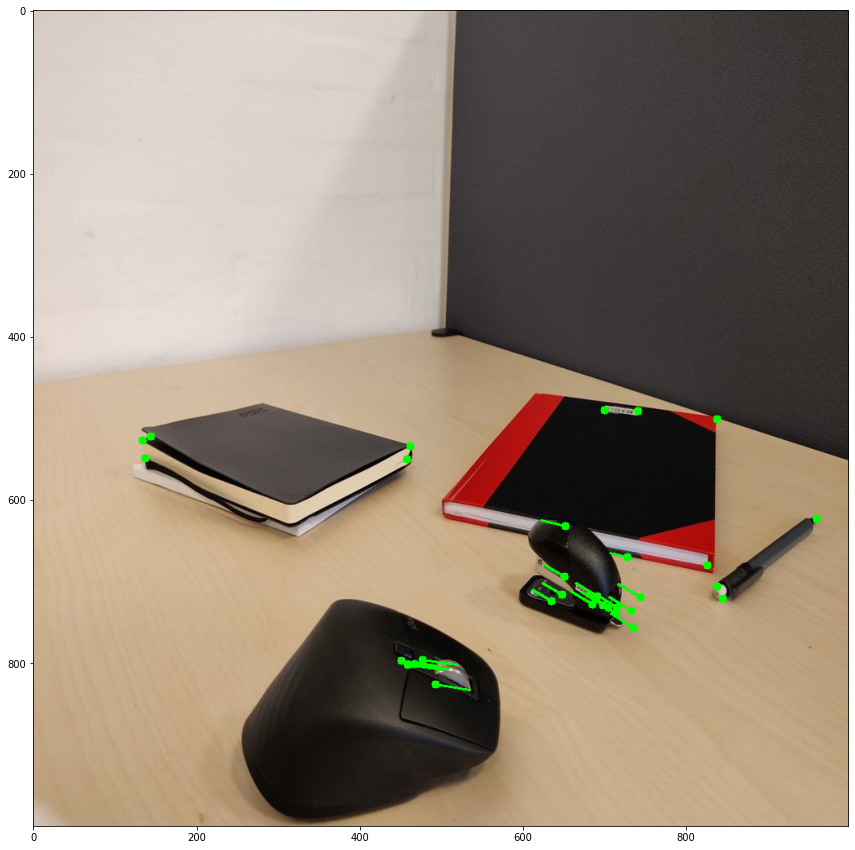

In [12]:
image2_copy = img2.copy()

# Loop through the features and draw the motion vectors
for i in range(len(feat1)):
    # Get the coordinates from the previous image (start point)
    f10=int(feat1[i][0][0])
    f11=int(feat1[i][0][1])
    # Get the coordinates from the current image (end point)
    f20=int(feat2[i][0][0])
    f21=int(feat2[i][0][1])

    # Draw a line connecting the start and end points (green line) to visualize motion
    cv2.line(image2_copy, (f10,f11), (f20, f21), (0, 255, 0), 2)
    # Draw the starting point (solid green circle)
    cv2.circle(image2_copy, (f10, f11), 5, (0, 255, 0), -1)

plt.figure(figsize=(15,15))
plt.imshow(image2_copy)

## Exercise 4a
Change the code such that only the keypoints that have moved will be showed in the image.


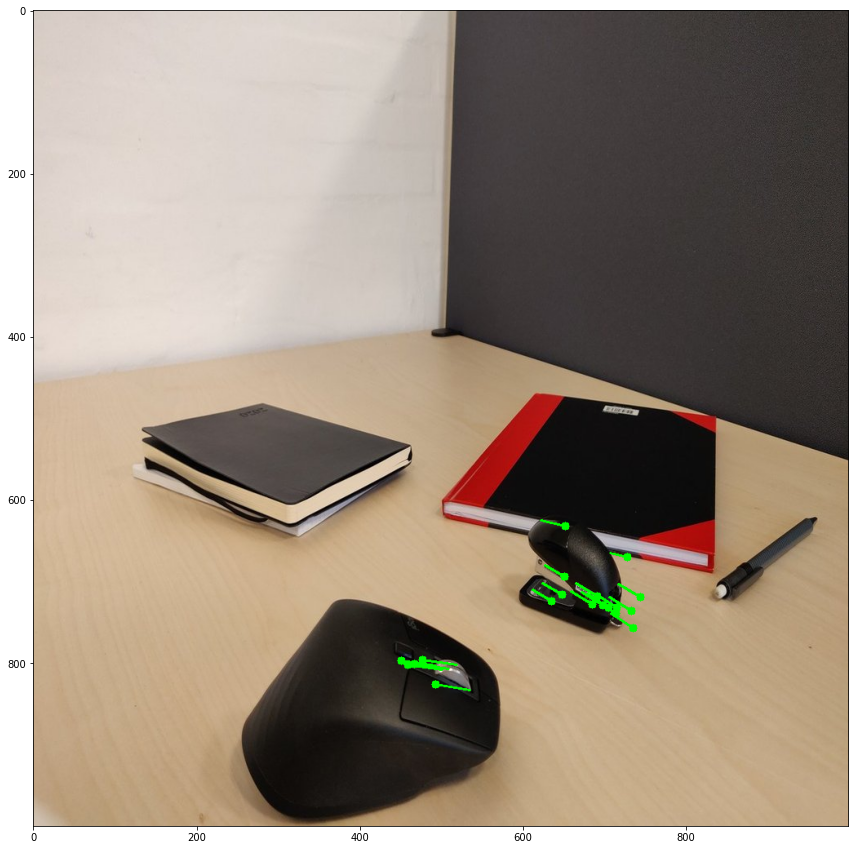

In [13]:
image2_copy = img2.copy()

for i in range(len(feat1)):
    f10=int(feat1[i][0][0])
    f11=int(feat1[i][0][1])
    f20=int(feat2[i][0][0])
    f21=int(feat2[i][0][1])

    # Calculate the absolute difference in x and y coordinates
    # If the change in position is very small (less than 2 pixels), we treat it as "no movement" (noise)
    # and skip drawing this feature.
    if np.abs(f10 - f20) < 2 and np.abs(f11 - f21) < 2:
        continue

    cv2.line(image2_copy, (f10,f11), (f20, f21), (0, 255, 0), 2)
    cv2.circle(image2_copy, (f10, f11), 5, (0, 255, 0), -1)

plt.figure(figsize=(15,15))
plt.imshow(image2_copy)

## Dense Optical Flow
The sparse optical flow finds the flow of the detected keypoints. We will now try to use dense optical flow which, finds the flow of all the points in the picture. 
For this example we use the same two images, so we don't have to load them again. To find the optical flow, we use the function [`cv2.calcOpticalFlowFarneback`](https://docs.opencv.org/4.7.0/dc/d6b/group__video__track.html#ga5d10ebbd59fe09c5f650289ec0ece5af). Check out the description to see what all the different parameters do, and try to change them to see the difference.

In [14]:
# Calculate Dense Optical Flow using Gunnar Farneback's algorithm
# cv2.calcOpticalFlowFarneback(prev, next, flow, pyr_scale, levels, winsize, iterations, poly_n, poly_sigma, flags)
# prev - first 8-bit single-channel input image.
# next - second input image of the same size and the same type.
# flow - computed flow image that has the same size as prev and type CV_32FC2.
# pyr_scale - parameter specifying the image scale (<1) to build pyramids for each image;
#     pyr_scale=0.5 means a classical pyramid, where each next layer is twice smaller than the previous one.
# levels - number of pyramid layers including the initial image; levels=1 means that no extra layers are created and only the original images are used.
# winsize - averaging window size; larger values increase the algorithm robustness to image noise and give more chances for fast motion detection, but yield more blurred motion field.
# iterations - number of iterations the algorithm does at each pyramid level.
# poly_n - size of the pixel neighborhood used to find polynomial expansion in each pixel;
#     larger values mean that the image will be approximated with smoother surfaces, yielding more robust algorithm and more blurred motion field, typically poly_n = 5 or 7.
# poly_sigma - standard deviation of the Gaussian that is used to smooth derivatives used as a basis for the polynomial expansion;
#     for poly_n=5, you can set poly_sigma=1.1, for poly_n=7, a good value would be poly_sigma=1.5.
flow = cv2.calcOpticalFlowFarneback(gray1, gray2, None, 0.5, 3, 15, 3, 5, 1.5, 0)

The function returns an array containing the flow vector for every pixel. This can be changed to a magnitude and an angle using the function [`cv2.cartToPolar`](https://docs.opencv.org/4.7.0/d2/de8/group__core__array.html#gac5f92f48ec32cacf5275969c33ee837d). 

# Exercise 4b
Find a way to represent the flow in the image, for example, by drawing vectors the relevant places or by making a new image with colors representing the flow of every pixel. An example of retrieving the magnitude and angle is shown below, which you can use if you like. 

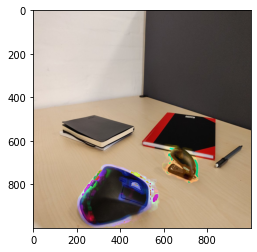

In [15]:
# Retrieve the magnitude and angle of every pixel
# cv2.cartToPolar(x, y)
# Calculates the magnitude and angle of 2D vectors.
# flow[:,:,0] contains the flow (displacement) in the x-direction (dx)
# flow[:,:,1] contains the flow (displacement) in the y-direction (dy)
# mag - magnitude of the motion (speed): $\sqrt{x^2 + y^2}$
# ang - angle of the motion (direction): $\arctan(y/x)$
mag, ang = cv2.cartToPolar(flow[:,:,0], flow[:,:,1])

### Fill in some code to represent the flow here ###

# Create an empty HSV image (Hue, Saturation, Value) to visualize the flow
# Hue will represent direction (angle), Value will represent speed (magnitude)
hsv = np.zeros_like(img1)

# Set the Hue (channel 0) according to the angle
# OpenCV Hue range is [0, 179], so we convert radians to degrees and divide by 2
hsv[:, :, 0] = ang * 180 / np.pi / 2

# Set the Saturation (channel 1) to maximum (255) to make colors vibrant
hsv[:, :, 1] = np.ones_like(img1[:, :, 0]) * 255

# Set the Value (channel 2) according to the magnitude
# We normalize the magnitude to the range [0, 255] using MinMax normalization
# This means faster movement will appear brighter, no movement will appear black
hsv[:, :, 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

# Convert the HSV image back to BGR color space so we can display it with Matplotlib (or OpenCV)
bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

# Display the flow visualization overlaid on the original image
# Note: Adding the images directly (img1 + bgr) might cause overflow/saturation artifacts,
# but gives a quick visual indication of where motion is happening on top of the structure.
plt.imshow(img1 + bgr)